In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Daily.csv')

# Create a 'Date' column from 'YEAR' and 'DOY'
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + ' ' + df['DOY'].astype(str), format='%Y %j')

# Set 'Date' as the index
df = df.set_index('Date')

# Sort the DataFrame by the new 'Date' index
df = df.sort_index()

# Replace all occurrences of -999 with NaN
df.replace(-999, np.nan, inplace=True)

print("DataFrame reloaded, 'Date' column created and set as index, sorted, and -999 replaced with NaN.")
print(df.head())

DataFrame reloaded, 'Date' column created and set as index, sorted, and -999 replaced with NaN.
            YEAR  DOY    T2M     TS   QV2M   RH2M  PRECTOTCORR      PS  WS2M  \
Date                                                                           
2015-01-01  2015    1  25.07  25.10  18.17  90.98         4.16  100.15  6.58   
2015-01-02  2015    2  24.47  25.51  14.68  77.26         0.48  100.58  2.05   
2015-01-03  2015    3  24.76  25.71  15.59  80.55         0.30  100.76  1.60   
2015-01-04  2015    4  25.15  25.97  15.25  77.17         0.13  100.71  0.89   
2015-01-05  2015    5  23.89  24.95  12.85  70.42         0.10  100.70  3.47   

            GWETTOP  GWETROOT  
Date                           
2015-01-01     0.58      0.43  
2015-01-02     0.55      0.43  
2015-01-03     0.53      0.42  
2015-01-04     0.52      0.42  
2015-01-05     0.51      0.42  


In [ ]:
for column in df.columns:
    if df[column].dtype in ['int64', 'float64']:
        if df[column].isnull().any():
            df[column].fillna(df[column].mean(), inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
YEAR           0
DOY            0
T2M            0
TS             0
QV2M           0
RH2M           0
PRECTOTCORR    0
PS             0
WS2M           0
GWETTOP        0
GWETROOT       0
dtype: int64


/tmp/ipython-input-1978029917.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)


In [ ]:
for column in df.columns:
    if df[column].dtype in ['int64', 'float64']:
        if df[column].isnull().any():
            df[column] = df[column].fillna(df[column].mean())

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
YEAR           0
DOY            0
T2M            0
TS             0
QV2M           0
RH2M           0
PRECTOTCORR    0
PS             0
WS2M           0
GWETTOP        0
GWETROOT       0
dtype: int64


In [ ]:
df['monthly_cumulative_rainfall'] = df['PRECTOTCORR'].rolling(window=30).sum()
df['monthly_average_temperature'] = df['T2M'].rolling(window=30).mean()
df['monthly_average_relative_humidity'] = df['RH2M'].rolling(window=30).mean()
df['monthly_average_root_zone_soil_moisture'] = df['GWETROOT'].rolling(window=30).mean()
df.dropna(inplace=True)
print("DataFrame with new monthly features and NaNs dropped:")
print(df.head())

DataFrame with new monthly features and NaNs dropped:
            YEAR  DOY    T2M     TS   QV2M   RH2M  PRECTOTCORR      PS  WS2M  \
Date                                                                           
2015-01-30  2015   30  23.81  24.97  13.46  74.04         0.00  100.96  2.30   
2015-01-31  2015   31  23.62  25.07  13.18  73.72         0.43  100.97  2.20   
2015-02-01  2015   32  22.88  24.39  10.25  60.87         0.75  101.01  3.10   
2015-02-02  2015   33  22.59  24.06  11.37  67.46         0.00  101.16  3.14   
2015-02-03  2015   34  23.11  24.07  10.73  62.24         0.00  101.31  3.13   

            GWETTOP  GWETROOT  monthly_cumulative_rainfall  \
Date                                                         
2015-01-30     0.44      0.35                         5.17   
2015-01-31     0.44      0.35                         1.44   
2015-02-01     0.45      0.35                         1.71   
2015-02-02     0.43      0.35                         1.41   
2015-02-03   

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Identify the monthly climate feature columns
monthly_features = [
    'monthly_cumulative_rainfall',
    'monthly_average_temperature',
    'monthly_average_relative_humidity',
    'monthly_average_root_zone_soil_moisture'
]

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the monthly feature columns
df[monthly_features] = scaler.fit_transform(df[monthly_features])

print("DataFrame with normalized monthly features:")
print(df[monthly_features].head())

DataFrame with normalized monthly features:
            monthly_cumulative_rainfall  monthly_average_temperature  \
Date                                                                   
2015-01-30                     0.012220                     0.153494   
2015-01-31                     0.003404                     0.148644   
2015-02-01                     0.004042                     0.143325   
2015-02-02                     0.003333                     0.136067   
2015-02-03                     0.003025                     0.129244   

            monthly_average_relative_humidity  \
Date                                            
2015-01-30                           0.153940   
2015-01-31                           0.133512   
2015-02-01                           0.114115   
2015-02-02                           0.098622   
2015-02-03                           0.080952   

            monthly_average_root_zone_soil_moisture  
Date                                                 

In [ ]:
df['Irrigation Index'] = (df['monthly_average_root_zone_soil_moisture'] + df['monthly_cumulative_rainfall']) / 2
df['Crop Index'] = (df['monthly_average_temperature'] + df['monthly_average_relative_humidity'] + df['monthly_average_root_zone_soil_moisture']) / 3
df['ACLI'] = (df['monthly_cumulative_rainfall'] + df['monthly_average_temperature'] + df['monthly_average_relative_humidity'] + df['monthly_average_root_zone_soil_moisture']) / 4

print("DataFrame with new agricultural indices:")
print(df[['Irrigation Index', 'Crop Index', 'ACLI']].head())

DataFrame with new agricultural indices:
            Irrigation Index  Crop Index      ACLI
Date                                              
2015-01-30          0.095296    0.161935  0.124506
2015-01-31          0.088658    0.152023  0.114868
2015-02-01          0.086748    0.142298  0.107734
2015-02-02          0.084442    0.133414  0.100894
2015-02-03          0.082338    0.123949  0.093718


In [ ]:
lower_bound = df['ACLI'].quantile(0.33)
upper_bound = df['ACLI'].quantile(0.66)

def assign_yield_feasibility(acli):
    if acli <= lower_bound:
        return 'Low'
    elif acli >= upper_bound:
        return 'High'
    else:
        return 'Medium'

df['Yield Feasibility'] = df['ACLI'].apply(assign_yield_feasibility)

print("Yield Feasibility categories and their counts:")
print(df['Yield Feasibility'].value_counts())

Yield Feasibility categories and their counts:
Yield Feasibility
High      1356
Low       1316
Medium    1316
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
import joblib
from google.colab import drive

drive.mount('/content/drive/')

# Re-load and preprocess the DataFrame 'df'
# (Steps from previous cells to ensure 'df' is defined and has required columns)
df = pd.read_csv('/content/drive/MyDrive/Daily.csv')
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + ' ' + df['DOY'].astype(str), format='%Y %j')
df = df.set_index('Date')
df = df.sort_index()
df.replace(-999, np.nan, inplace=True)

# Fill missing numerical values
for column in df.columns:
    if df[column].dtype in ['int64', 'float64']:
        if df[column].isnull().any():
            df[column] = df[column].fillna(df[column].mean())

# Generate monthly features
df['monthly_cumulative_rainfall'] = df['PRECTOTCORR'].rolling(window=30).sum()
df['monthly_average_temperature'] = df['T2M'].rolling(window=30).mean()
df['monthly_average_relative_humidity'] = df['RH2M'].rolling(window=30).mean()
df['monthly_average_root_zone_soil_moisture'] = df['GWETROOT'].rolling(window=30).mean()
df.dropna(inplace=True)

# Normalize monthly features
monthly_features = [
    'monthly_cumulative_rainfall',
    'monthly_average_temperature',
    'monthly_average_relative_humidity',
    'monthly_average_root_zone_soil_moisture'
]
scaler = MinMaxScaler()
df[monthly_features] = scaler.fit_transform(df[monthly_features])
df['Irrigation Index'] = (df['monthly_average_root_zone_soil_moisture'] + df['monthly_cumulative_rainfall']) / 2
df['Crop Index'] = (df['monthly_average_temperature'] + df['monthly_average_relative_humidity'] + df['monthly_average_root_zone_soil_moisture']) / 3
df['ACLI'] = (df['monthly_cumulative_rainfall'] + df['monthly_average_temperature'] + df['monthly_average_relative_humidity'] + df['monthly_average_root_zone_soil_moisture']) / 4
X = df[monthly_features]
y_regression = df[['Irrigation Index', 'Crop Index', 'ACLI']]
split_point = int(len(df) * 0.8)
X_train = X.iloc[:split_point]
y_regression_train = y_regression.iloc[:split_point]

target_columns = ['Irrigation Index', 'Crop Index', 'ACLI']

for col in target_columns:
    print(f"Training model for {col}...")
    regression_model = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )
    regression_model.fit(X_train, y_regression_train[col])

    filename = f"/content/drive/MyDrive/{col.lower().replace(' ', '_')}_regressor.pkl"
    joblib.dump(regression_model, filename)
    print(f"Gradient Boosting Regressor for {col} trained and saved as {filename}.")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Training model for Irrigation Index...
Gradient Boosting Regressor for Irrigation Index trained and saved as /content/drive/MyDrive/irrigation_index_regressor.pkl.
Training model for Crop Index...
Gradient Boosting Regressor for Crop Index trained and saved as /content/drive/MyDrive/crop_index_regressor.pkl.
Training model for ACLI...
Gradient Boosting Regressor for ACLI trained and saved as /content/drive/MyDrive/acli_regressor.pkl.


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive
drive.mount('/content/drive/')

df = pd.read_csv('/content/drive/MyDrive/Daily.csv')
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + ' ' + df['DOY'].astype(str), format='%Y %j')
df = df.set_index('Date')
df = df.sort_index()
df.replace(-999, np.nan, inplace=True)
for column in df.columns:
    if df[column].dtype in ['int64', 'float64']:
        if df[column].isnull().any():
            df[column] = df[column].fillna(df[column].mean())
df['monthly_cumulative_rainfall'] = df['PRECTOTCORR'].rolling(window=30).sum()
df['monthly_average_temperature'] = df['T2M'].rolling(window=30).mean()
df['monthly_average_relative_humidity'] = df['RH2M'].rolling(window=30).mean()
df['monthly_average_root_zone_soil_moisture'] = df['GWETROOT'].rolling(window=30).mean()
df.dropna(inplace=True)
monthly_features = [
    'monthly_cumulative_rainfall',
    'monthly_average_temperature',
    'monthly_average_relative_humidity',
    'monthly_average_root_zone_soil_moisture'
]
scaler = MinMaxScaler()
df[monthly_features] = scaler.fit_transform(df[monthly_features])
df['Irrigation Index'] = (df['monthly_average_root_zone_soil_moisture'] + df['monthly_cumulative_rainfall']) / 2
df['Crop Index'] = (df['monthly_average_temperature'] + df['monthly_average_relative_humidity'] + df['monthly_average_root_zone_soil_moisture']) / 3
df['ACLI'] = (df['monthly_cumulative_rainfall'] + df['monthly_average_temperature'] + df['monthly_average_relative_humidity'] + df['monthly_average_root_zone_soil_moisture']) / 4
lower_bound = df['ACLI'].quantile(0.33)
upper_bound = df['ACLI'].quantile(0.66)

def assign_yield_feasibility(acli):
    if acli <= lower_bound:
        return 'Low'
    elif acli >= upper_bound:
        return 'High'
    else:
        return 'Medium'

df['Yield Feasibility'] = df['ACLI'].apply(assign_yield_feasibility)

X = df[monthly_features]
y_classification = df['Yield Feasibility']
split_point = int(len(df) * 0.8)

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]
y_classification_train = y_classification.iloc[:split_point]
y_classification_test = y_classification.iloc[split_point:]

classification_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

classification_model.fit(X_train, y_classification_train)

joblib.dump(classification_model, "/content/drive/MyDrive/gradient_boosting_classifier.pkl")

print("Gradient Boosting Classifier trained and saved successfully.")
print(f"X_test shape: {X_test.shape}")
print(f"y_classification_test shape: {y_classification_test.shape}")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Gradient Boosting Classifier trained and saved successfully.
X_test shape: (798, 4)
y_classification_test shape: (798,)


Regression models loaded successfully.

Regression Model Evaluation:

Irrigation Index:
  MAE: 0.0107
  RMSE: 0.0152
  R^2: 0.9967

Crop Index:
  MAE: 0.0166
  RMSE: 0.0238
  R^2: 0.9863

ACLI:
  MAE: 0.0165
  RMSE: 0.0238
  R^2: 0.9875


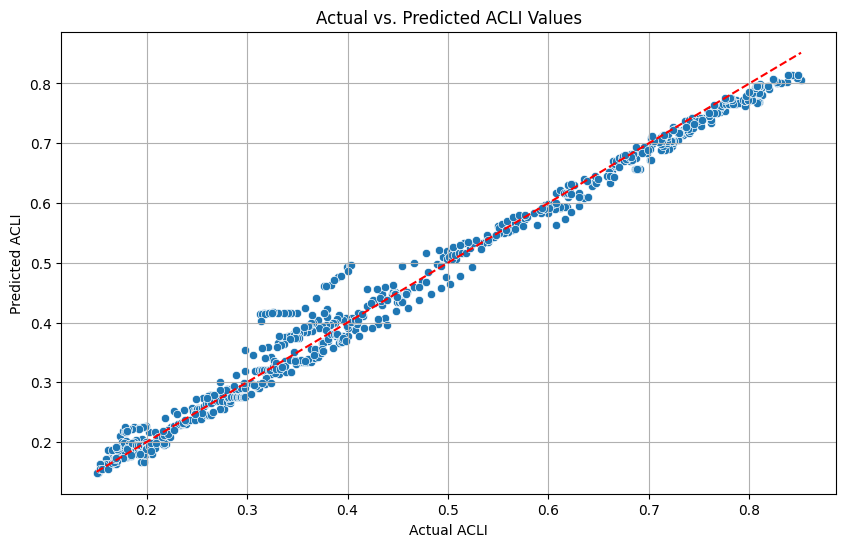

In [ ]:
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define y_regression and split to get y_regression_test, as it was not defined in the last successful run
y_regression = df[['Irrigation Index', 'Crop Index', 'ACLI']]
split_point = int(len(df) * 0.8)
y_regression_test = y_regression.iloc[split_point:]

# Load the saved regression models
irrigation_model = joblib.load('/content/drive/MyDrive/irrigation_index_regressor.pkl')
crop_model = joblib.load('/content/drive/MyDrive/crop_index_regressor.pkl')
acli_model = joblib.load('/content/drive/MyDrive/acli_regressor.pkl')

print("Regression models loaded successfully.")

# Make predictions for each model on X_test
y_pred_irrigation = irrigation_model.predict(X_test)
y_pred_crop = crop_model.predict(X_test)
y_pred_acli = acli_model.predict(X_test)

# Create a DataFrame for predictions
y_regression_pred_df = pd.DataFrame({
    'Irrigation Index': y_pred_irrigation,
    'Crop Index': y_pred_crop,
    'ACLI': y_pred_acli
}, index=X_test.index) # Use X_test index to align with y_regression_test

print("\nRegression Model Evaluation:")
for col in y_regression_test.columns:
    mae = mean_absolute_error(y_regression_test[col], y_regression_pred_df[col])
    rmse = np.sqrt(mean_squared_error(y_regression_test[col], y_regression_pred_df[col]))
    r2 = r2_score(y_regression_test[col], y_regression_pred_df[col])

    print(f"\n{col}:")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R^2: {r2:.4f}")

# Visualize actual vs. predicted ACLI values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_regression_test['ACLI'], y=y_regression_pred_df['ACLI'])
plt.xlabel('Actual ACLI')
plt.ylabel('Predicted ACLI')
plt.title('Actual vs. Predicted ACLI Values')
plt.plot([y_regression_test['ACLI'].min(), y_regression_test['ACLI'].max()],
         [y_regression_test['ACLI'].min(), y_regression_test['ACLI'].max()],
         'r--') # Add a diagonal line for perfect prediction
plt.grid(True)
plt.show()

Gradient Boosting Classifier loaded successfully.

Classification Model Evaluation:
Accuracy: 0.9261

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.96      0.98       269
         Low       0.94      0.87      0.91       269
      Medium       0.85      0.95      0.89       260

    accuracy                           0.93       798
   macro avg       0.93      0.93      0.93       798
weighted avg       0.93      0.93      0.93       798



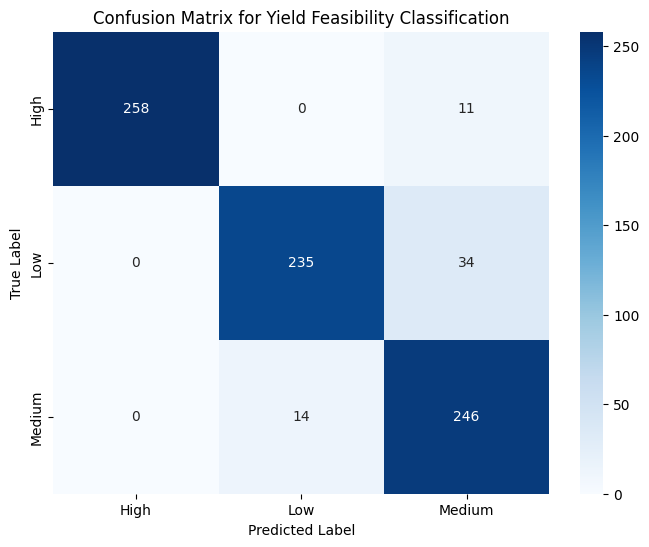

In [ ]:
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the saved classification model
classification_model = joblib.load('/content/drive/MyDrive/gradient_boosting_classifier.pkl')
print("Gradient Boosting Classifier loaded successfully.")

# Predict the 'Yield Feasibility' using the classification model
y_classification_pred = classification_model.predict(X_test)

print("\nClassification Model Evaluation:")

# Calculate and print Accuracy
accuracy = accuracy_score(y_classification_test, y_classification_pred)
print(f"Accuracy: {accuracy:.4f}")

# Calculate and print Precision, Recall, F1-score for each class
print("\nClassification Report:")
print(classification_report(y_classification_test, y_classification_pred))

# Generate Confusion Matrix
classes = sorted(y_classification_test.unique())
cm = confusion_matrix(y_classification_test, y_classification_pred, labels=classes)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Yield Feasibility Classification')
plt.show()

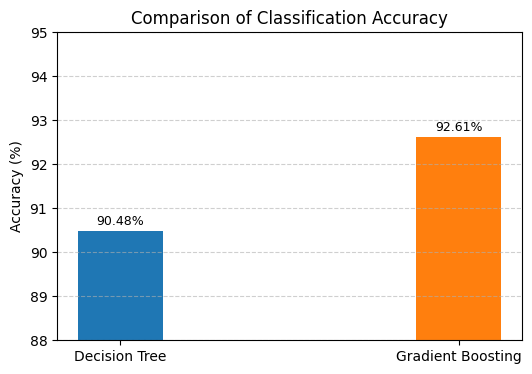

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and accuracy values
models = ['Decision Tree', 'Gradient Boosting']
accuracy = [90.48, 92.61]

# IJCS-style colors
colors = ['#1f77b4', '#ff7f0e']  # Blue, Orange

x = np.arange(len(models))

plt.figure(figsize=(6, 4))

# Thin bars (key change: width=0.25)
bars = plt.bar(x, accuracy, color=colors, width=0.25)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.15,
             f'{height:.2f}%',
             ha='center', fontsize=9)

# Axis labels and title
plt.xticks(x, models)
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Classification Accuracy')

plt.ylim(88, 95)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


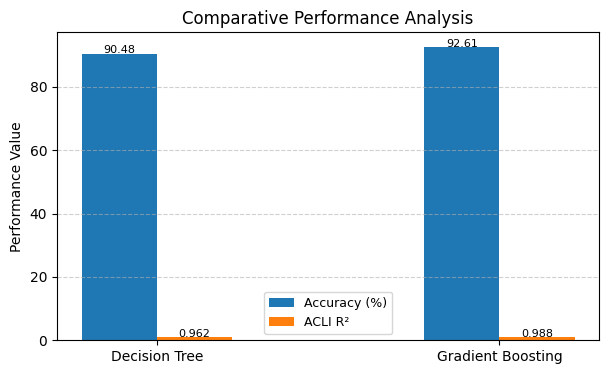

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Decision Tree', 'Gradient Boosting']

accuracy = [90.48, 92.61]
acli_r2 = [0.9622, 0.9875]

x = np.arange(len(models))
width = 0.22  # Thin bars

plt.figure(figsize=(7, 4))

plt.bar(x - width/2, accuracy, width,
        label='Accuracy (%)',
        color='#1f77b4')

plt.bar(x + width/2, acli_r2, width,
        label='ACLI R²',
        color='#ff7f0e')

# Value labels
for i in range(len(models)):
    plt.text(x[i] - width/2, accuracy[i] + 0.15,
             f'{accuracy[i]:.2f}',
             ha='center', fontsize=8)
    plt.text(x[i] + width/2, acli_r2[i] + 0.01,
             f'{acli_r2[i]:.3f}',
             ha='center', fontsize=8)

plt.xticks(x, models)
plt.ylabel('Performance Value')
plt.title('Comparative Performance Analysis')
plt.legend(fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()
